# ML Models Crash Course Notebook
## In This Notebook We Explore The Various Different Machine Learning Models Used to Predict Different Outcomes From The Kaggle Housing dataset 

----

In [17]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier  # import the model for random forest classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Import the Dataset from Kaggle

In [18]:
# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print("Path to dataset files:", df)
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas


# Find the CSV file downloaded by KaggleHub and load it as a DataFrame
csv_files = [
  os.path.join(root, filename)
  for root, _, files in os.walk(df)
  for filename in files
  if filename.lower().endswith(".csv")
]

if not csv_files:
  raise FileNotFoundError(f"No CSV files found in: {df}")

file_path = csv_files[0]
df = pd.read_csv(file_path)

print("First 5 records:")
print(df.head())

Path to dataset files: /Users/claudiafarkas/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1
First 5 records:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        

### Plot the imported raw data on a scatter plot

Text(0, 0.5, 'Price')

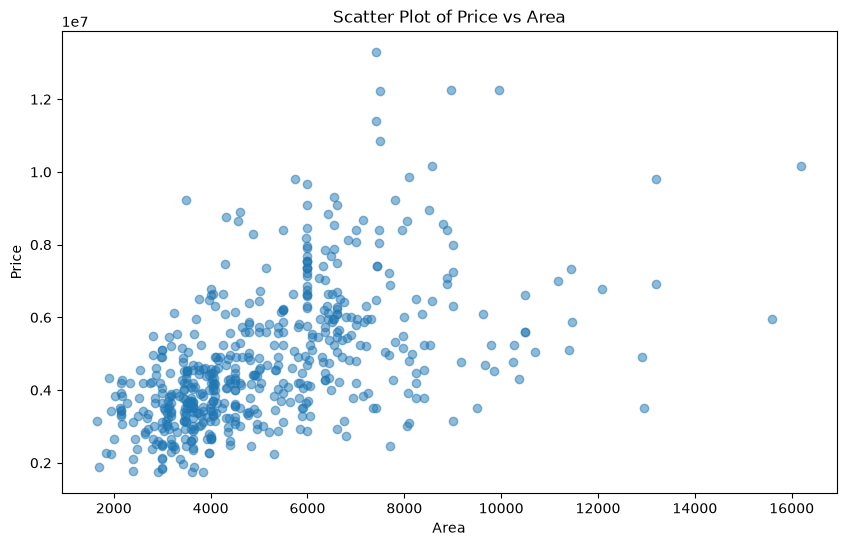

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['area'], df['price'], alpha=0.5)
plt.title('Scatter Plot of Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')

----

# **We Introduce Models to Help Represent the Data in Different Ways**

## Supervized Learning Models - *Models that are learning based on labeled test data (the type of problem can be either regression based or classificaiton based)*
### 1. Linear Regression: Predicts a continuous numeric value, such as a house price or temperature.
### 2. Logistic Regression: Predicts a binary category, such as whether an email is spam or not spam.Decision Trees: Splits data into branches based on simple rules to make a choice or classification.
### 3. Decision Trees : Works like a flowchart, by breaking down a complex dataset into smaller, more manageable subsets based on sequential, logic-based questions.
### 4. Random Forests: Combines many decision trees together to make more accurate and stable predictions.
### 5. Gradient Boosted Models (GBMs / XGBoost): Builds trees sequentially to correct previous errors, making them top performers for tabular data
----
____

## 1. Linear Regression Model

A method used to find the relationship between a dependent variable and one or more independent variables by fitting a straight line to data. It helps predict future values or measure how strongly variables affect each other. 

- Y = a + bX is the standard formula for simple linear regression. (Y = mx + b as learned in algrebra class to plot a line)
- Y: The dependent variable (what you want to predict).
- X: The independent variable (the predictor).
- b: The slope of the line, showing the change in Y for every unit change in X.
- a: The Y-intercept, showing the value of Y when X is zero

The linear model's Coefficient: 461.9748942727831, Intercept: 2387308.4823964317 provides insight into the relationship between area and price.
The coefficient indicates how much the price is expected to increase for each additional unit of area, in this case we see the value is 461.9748942727831, meaning for every additional unit of area, the price is expected to increase by 461.9748942727831 units. 
The intercept represents the expected price when the area is zero, in this case we see the value is 2387308.4823964317, meaning when the area is zero, the expected price is 2387308.4823964317 units.
So, the increase of the coefficient and the intercept mean that the price is expected to increase as the area increases, and the intercept indicates that there is a base price even when the area is zero.


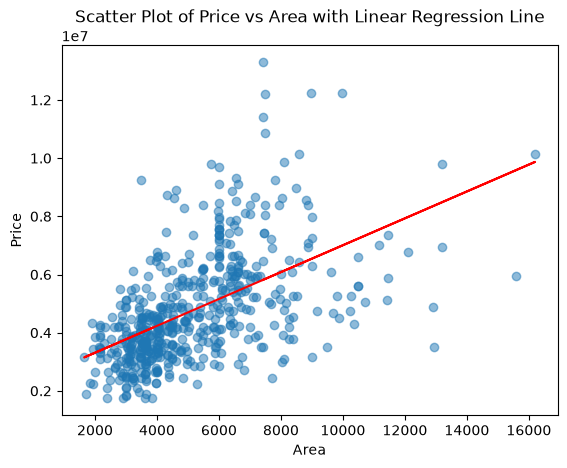

In [20]:
X = df[['area']]
y = df['price'] 

reg = LinearRegression()
reg.fit(X, y)
print(f"The linear model's Coefficient: {reg.coef_[0]}, Intercept: {reg.intercept_} provides insight into the relationship between area and price.")
print(f"The coefficient indicates how much the price is expected to increase for each additional unit of area, in this case we see the value is {reg.coef_[0]}, meaning for every additional unit of area, the price is expected to increase by {reg.coef_[0]} units. "
      f"\nThe intercept represents the expected price when the area is zero, in this case we see the value is {reg.intercept_}, meaning when the area is zero, the expected price is {reg.intercept_} units."
      f"\nSo, the increase of the coefficient and the intercept mean that the price is expected to increase as the area increases, and the intercept indicates that there is a base price even when the area is zero.")

plt.scatter(df['area'], df['price'], alpha=0.5)
plt.plot(df['area'], reg.predict(X), color='red')
plt.title('Scatter Plot of Price vs Area with Linear Regression Line')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()


### Graph Explination:
Shows the relationship between the area (X) of a house and its price (Y), along with the fitted linear regression line. 
The line suggests a **positive** correlation between area and price, *indicating that as the area increases, the price tends to increase as well.*

In [21]:
exog = sm.add_constant(X)  # Adds a constant term (intercept) to the predictor matrix, why? because in linear regression, we often want to include an intercept term in the model to account for the baseline level of the dependent variable when all predictors are zero.
# This allows the model to fit a line that doesn't necessarily pass through the origin (0,0), which is important for accurately capturing the relationship between the independent and dependent variables - most real-world relationships have a baseline value even when the predictor is zero.
# "exog" stands for "exogenous" variables - statsmodels' term for the independent/predictor variables in the model. Here, exog includes area plus a constant term (the intercept).

model = sm.OLS(y, exog).fit()  # Fits the OLS regression model and estimates the coefficients, why? because OLS (Ordinary Least Squares) is a method for estimating the parameters in a linear regression model by finding the best-fitting line that minimizes the sum of squared differences between the observed values and the values predicted by the model (i.e., minimizing the residuals squared - hence "Ordinary Least Squares").
# The .fit() method performs this estimation and returns a results object that contains information about the fitted model, including coefficients, statistical tests, and goodness-of-fit measures.

print(model.summary())  # Print the summary of the regression results



                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     218.9
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           7.39e-42
Time:                        20:10:34   Log-Likelihood:                -8551.2
No. Observations:                 545   AIC:                         1.711e+04
Df Residuals:                     543   BIC:                         1.712e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.387e+06   1.74e+05     13.681      0.0

### Summary Explination:

Key metrics worth understanding:
- *F-statistic* (218.9): tests the overall significance of the model - a higher value means the model (with area as predictor) fits significantly better than a model with no predictors *(paired with Prob (F-statistic) = 7.39e-42, this confirms the model as a whole is highly statistically significant)*
- *p-values* for each coefficient (0.000 for area and const): tests the null hypothesis that the coefficient is equal to zero (no effect) *(a low p-value means we reject that null hypothesis, indicating area is a statistically significant predictor of price)*.
- *R-squared value* (0.287): indicates that only ~28.7% of the variability in housing prices is explained by area *(a higher R-squared means a better fit, so 0.287 reflects a fairly modest fit - most of the variation in price is NOT explained by area alone)*.
- Considering the key metrics, we can conclude that the linear regression model **is statistically significant** and area **is** a meaningful predictor of housing prices, but it explains only a limited portion of price variability on its own *(statistical significance ≠ strong explanatory power - the model would likely benefit from additional predictors)*.
- Diagnostics also raise some concerns: Durbin-Watson (0.565) suggests notable positive autocorrelation in the residuals, and Omnibus/Jarque-Bera p-values (~0.000) indicate the residuals are not normally distributed - both suggest some OLS assumptions may be violated, so *results should be interpreted with some caution*.


----
## 2. Logistic Regression 

The statistical method used to predict the probability of a binary outcome (a "yes" or "no" answer)
It takes a standard linear equation and passing it through a mathematical function called the Sigmoid Function (or logistic function).
This function acts like a pair of walls that squishes the straight line into a smooth, S-shaped curve that never goes below 0 or goes above 1.

- P is the predicted probability.
- a + bX is the familiar linear equation (intercept + slope × input).
- e is Euler's constant (≈ 2.718)


Note: We must add a new target column to get started first. 
- E.g. "Is the house a Luxury House? (1 = Yes, 0 = No)" based on a price threshold (e.g., any house over $1,000,000).

In [22]:
df['target_luxury_house'] = df['price'] > 1000000 
#Q: why use price here if comapred to area later? because we are trying to predict whether a house is a luxury house based on its price, and we are using the area as the independent variable to make that prediction.
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,target_luxury_house
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,True
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,True
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,True
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,True
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,True


In [23]:
logistic_reg_model = LogisticRegression()  # define the logistic regression model used to model the probability of a binary outcome (whether a house is a luxury house or not) based on one or more predictor variables (here, area)

# Define the target BEFORE splitting - the median-price threshold must exist first
luxury_threshold = df['price'].median() # Use the median price so both classes are represented. why? because using the median as the threshold guarantees a roughly 50/50 split between luxury and non-luxury houses.
# This balanced representation helps the model learn from both classes properly - an imbalanced threshold could bias the model toward the majority class and hurt performance on the minority class.
df['target_luxury_house'] = (df['price'] >= luxury_threshold).astype(int)  # target variable: 1 if price >= median, else 0 
# Q: what is median in this case? The median is the middle value of the price column when sorted. So if price is greater than or equal to the median price, it is classified as a luxury house (1), otherwise it is not (0). This creates a binary target variable for the logistic regression model.


# standard split train & test step
X_train, X_test, y_train, y_test = train_test_split(
    X,  # the independent variable (area)
    df['target_luxury_house'],  # the dependent variable, already integer-typed above
    test_size=0.2,  # 20% of data reserved for testing, 80% for training - adjustable based on dataset size and desired train/test balance
    random_state=42,  # seed value to ensure reproducibility of the random split
    stratify=df['target_luxury_house']  # ensures both classes are proportionally represented in train and test sets, why? because this matters most for imbalanced datasets - stratifying prevents one split from accidentally getting too few examples of one class, helping the model learn and generalize better
)

if y_train.nunique() < 2:  # check that the training data contains both classes (0 and 1); if not, raise an error. 
    raise ValueError("The training data must contain both target classes.")

# define the predictive model
logistic_reg_model.fit(X_train, y_train)  # fit the logistic regression model to the training data, estimating the coefficients that best describe the relationship between area and the probability of a house being luxury. "fit" means the model is learning from the training data to find the best-fitting logistic curve that separates luxury houses from non-luxury houses based on area.
y_prob = logistic_reg_model.predict_proba(X_test)[:, 1]  # predicted probabilities of the positive class (target_luxury_house = 1) for the test set
# this gives the model's confidence in its predictions, rather than just a binary label
x_train_const= sm.add_constant(X_train)  # adds a constant term to X_train for the logistic regression model, why? because this is necessary for estimating the intercept of the logistic regression equation, same as with OLS

# define a separate model:
# used to get a bigger picture; helps us understand the relationship between area and the log-odds of a house being luxury, and to assess the statistical significance of area as a predictor. and give us metrics such as p-values, z-stats and pseudo R-squared, which are not provided by sklearn's LogisticRegression.
logit_model = sm.Logit(y_train, x_train_const)  # ensure the same training data is used for this model as was used for the sklearn logistic regression model, so we can compare results. "Logit" refers to the logistic regression model that models the log-odds of the target variable as a linear combination of the predictors.
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.587214
         Iterations 6
                            Logit Regression Results                           
Dep. Variable:     target_luxury_house   No. Observations:                  436
Model:                           Logit   Df Residuals:                      434
Method:                            MLE   Df Model:                            1
Date:                 Fri, 28 Aug 2026   Pseudo R-squ.:                  0.1528
Time:                         20:10:34   Log-Likelihood:                -256.03
converged:                        True   LL-Null:                       -302.19
Covariance Type:             nonrobust   LLR p-value:                 7.310e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7650      0.350     -7.907      0.000      -3.450      -2.080
area           0.0006

### Summary Explanation
- The coefficients show the relationship between area and the log-odds of a house being luxury.
- The p-value for area is found under "P>|z|" (a z-stat, not a t-stat, since this is a logit/MLE model rather than OLS) - here it's 0.000, well below the 0.05 significance threshold, indicating area IS a statistically significant predictor of luxury-house status.
- The model's pseudo R-squared is 0.1528, which is a modest fit - McFadden's pseudo R-squared (used by statsmodels) is generally considered good in the 0.2-0.4 range, so 0.1528 suggests area alone captures some, but not most, of what separates luxury from non-luxury houses.
- Note: pseudo R-squared isn't directly comparable to OLS R-squared on the same scale, so this shouldn't be read as a strict "stronger/weaker fit" comparison to the earlier OLS model.

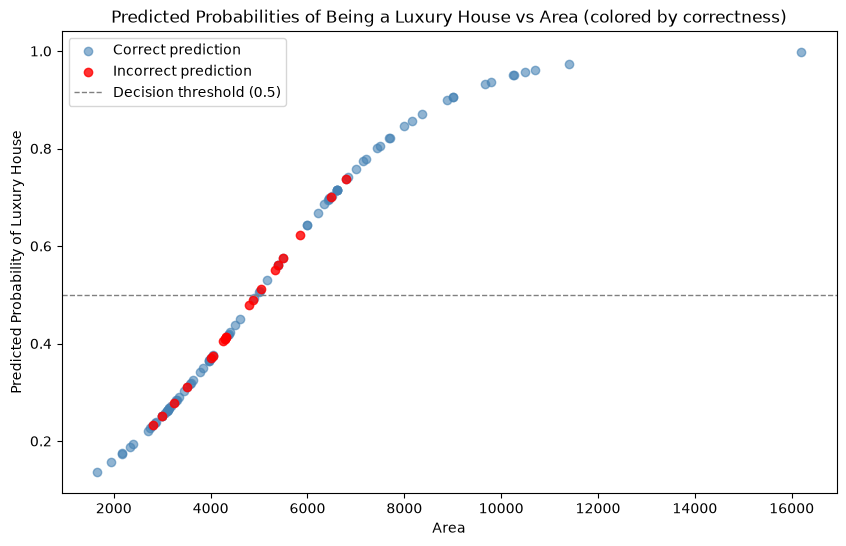

In [24]:
# show the predicted probabilities of being a luxury house for the test set on a graph
# Visualize correct vs incorrect predictions on the probability curve
y_pred = logistic_reg_model.predict(X_test) # predict the binary outcomes (0 or 1) for the test set (X_test) using the fitted logistic regression model.
correct = (y_test.values == y_pred)  # boolean array: True where prediction matched the true label

plt.figure(figsize=(10, 6))
plt.scatter(X_test.loc[correct], y_prob[correct], 
            color='steelblue', alpha=0.6, label='Correct prediction')
plt.scatter(X_test[~correct], y_prob[~correct], 
            color='red', alpha=0.8, label='Incorrect prediction')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
plt.xlabel('Area')
plt.ylabel('Predicted Probability of Luxury House')
plt.title('Predicted Probabilities of Being a Luxury House vs Area (colored by correctness)')
plt.legend()
plt.show()

### Graph Explanation

- Looking back at the fit code *logistic_reg_model.fit(X_train, y_train)*, the model learns from the training data to find the best-fitting logistic curve that separates luxury houses from non-luxury houses based on area. This graph is almost like a "fine-tuned version" of the linear regression graph created previously.
- Each point represents a house in the test set, with the x-axis showing the area and the y-axis showing the predicted probability of being a luxury house. The plot helps visualize how the model's predictions vary with the area of the houses.
- The red points show where `predict()` got the classification wrong. Notice how they cluster close to the decision threshold (0.5) — that's the direct visual evidence of the model's genuine uncertainty near the cutoff point where it decides "luxury" vs. "not luxury."
- For every house in the test set, the model outputs a probability between 0 and 1 that it's luxury, based on area. Small areas → probability near 0; large areas → probability near 1; mid-sized areas → probability hovers around 0.5, where the model is genuinely uncertain.

Text(0, 0.5, 'True Labels')

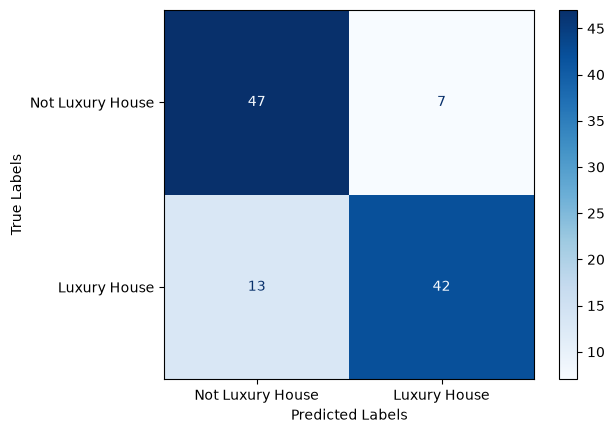

In [25]:

cm = confusion_matrix(y_test, y_pred) # compute the confusion matrix to evaluate the accuracy of the classification model by comparing the true labels (y_test) with the predicted labels (y_pred).
y_axis_labels = ['Not Luxury House', 'Luxury House'] # define the labels for the y-axis of the confusion matrix plot, corresponding to the two classes in the target variable (target_luxury_house).
x_axis_labels = ['Not Luxury House', 'Luxury House'] # define the labels for the x-axis of the confusion matrix plot, corresponding to the two classes in the target variable (target_luxury_house).
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=x_axis_labels) # create a ConfusionMatrixDisplay object to visualize the confusion matrix, using the computed confusion matrix (cm) and the class labels from the logistic regression model (logistic_reg_model.classes_).
disp.plot(cmap=plt.cm.Blues) # plot the confusion matrix using a blue color map for better visualization. The confusion matrix provides a summary of the model's performance, showing the number
disp.ax_.set_xlabel('Predicted Labels')
disp.ax_.set_ylabel('True Labels')


### Graph Explination

- This confusion matrix summarizes the same predictions shown in the probability plot above, but as hard 0/1 classifications rather than continuous probabilities. Each cell counts how many test-set houses fell into a given combination of true label vs. predicted label.
- The diagonal cells (47 and 42) are the houses the model got right — 47 correctly identified as "Not Luxury" and 42 correctly identified as "Luxury." 
- The off-diagonal cells (7 and 13) are the errors: 7 houses were actually not luxury but predicted luxury (false positives), and 13 houses were actually luxury but predicted not luxury (false negatives).
- This connects directly to the probability plot: the red (incorrect) points in that graph are exactly the houses being counted in the 7 and 13 error cells here. Because those houses had predicted probabilities close to the 0.5 threshold, a small shift in area was enough to push them across the decision boundary and flip the prediction.
- Overall accuracy from this matrix is (47 + 42) / 109 ≈ 82%. The confusion matrix essentially "collapses" the probability plot's spectrum of confidence into four counts, trading away the nuance of *how* confident the model was for a simpler, more direct performance summary.

In [26]:
# how could bayes theorem be applied to this problem?
# Bayes' theorem could be applied to this problem by using it to update the probability of a house being a luxury house based on new evidence (the area of the house). 
# For example, we could calculate the prior probability of a house being a luxury house (based on historical data), and then use Bayes' theorem to update that probability based on the area of a specific house    


---
## 3. Decision Trees

This model is like a flowchart, it splits the using yes-or-no rules based on features to predict a class or value. 

- Root: The start point at the top containing all data.
- Internal nodes: Points that split data using specific feature tests.
- Leaf nodes: The end points that show the final prediction or label.

Note: they can be regression *and* classification type trees. A Decision Tree Regressor and a Decision Tree Classifier work by the exact same splitting logic, they just differ in what happens at the very end (the leaf node):
- Classifier: leaf node predicts the majority class among the training examples that landed there (e.g. "most houses here were luxury, so predict luxury")
- Regressor: leaf node predicts the average of the target values among the training examples that landed there (e.g. "houses here average $650k, so predict $650k")-

Tree depth isn't about how many output categories you have — it's about how many features you have to split on, and what kind they are.



Let's ask the right question: *how many rentable sections does the house have? The target (0, 1, or 2 rentable sections)*

Q: Why should we ask a different type of question for this model? 
- Rentable spaces (basement + guestroom): few features, both binary so depth is structurally limited no matter what, and that's fine, the tree can still separate 0/1/2 counts cleanly since it has 2 informative binary questions to combine.
- Luxury from area: one continuous feature so depth is not structurally limited, but going deeper than necessary would just mean the tree is memorizing noise instead of finding the real pattern, since one feature alone can only tell you so much about something as complex as "luxury."
So the more useful question to ask with trees isn't "will this create enough depth-" — it's "do I have enough distinct, informative features for the tree to combine?" One feature (area) gives you a shallow, honest tree. Two binary features (basement, guestroom) give you a slightly richer one. Ten relevant features would let a tree get genuinely deep and start capturing real interactions between them — which is where trees start to shine over something like logistic regression. (*so technically the more features we cna derive from a question the better and more usefult he outcome of the tree would be.*)

#### Feature Engineering
How can we add even more features to the tree to create a more meaningful result? Let's add another column values with the question!:  *How ready are the spaces?*
- Using the column 'furnishedstatus' we see ordinal values (furnished > semi-furnished > unfurnished, in terms of rental readiness). We assume that a furnished basement is more realistically rentable than an unfurnished one.

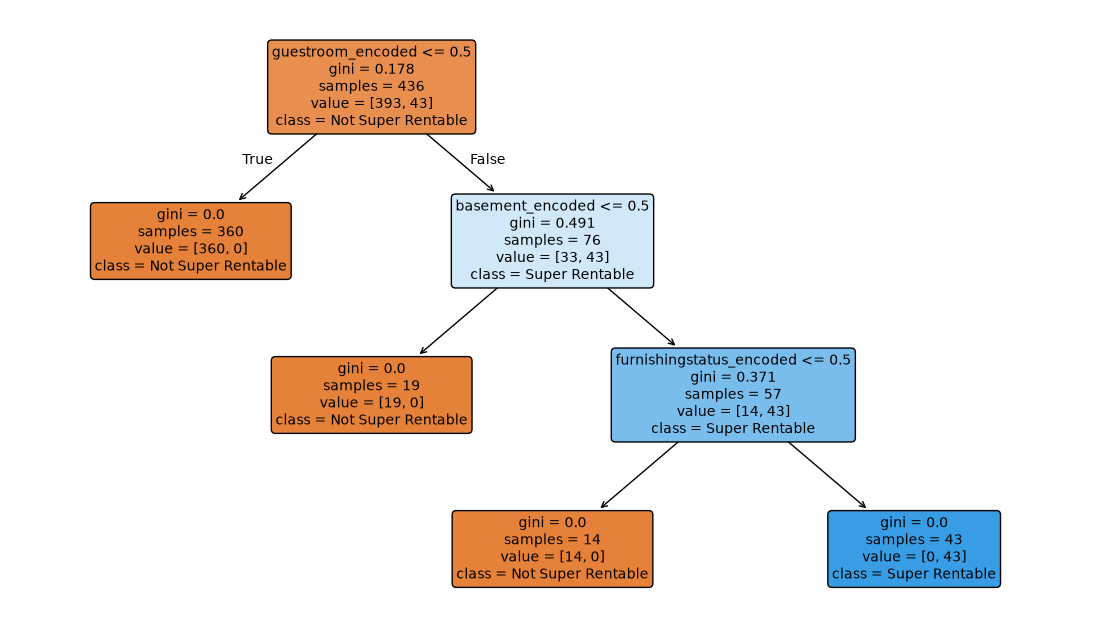

Accuracy: 1.0
[[98  0]
 [ 0 11]]


In [27]:
# state the conditions
df['rentable_spaces'] = (df['basement'] == 'yes').astype(int) + (df['guestroom'] == 'yes').astype(int)  # rentable_spaces = 0 (neither basement nor guestroom), rentable_spaces = 1 (either basement or guestroom), rentable_spaces = 2 (both basement and guestroom)
df['super_rentable'] = ((df['rentable_spaces'] == 2) & (df['furnishingstatus'] != 'unfurnished')).astype(int)   # super_rentable = 1 if both basement and guestroom exist AND at least one is furnished/semi-furnished, else 0

# encoding the categorical variables into numerical format
# why? because we need to convert categorical variables (like furnishing status) into a numerical format that the model can understand. This mapping allows us to represent the different furnishing statuses as integers, which can then be used as features in our predictive models.
furnish_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}   # define a mapping from furnishing status to numerical values for encoding categorical data into numerical format. 
df['furnishingstatus_encoded'] = df['furnishingstatus'].map(furnish_map)    # encode furnishing status as numerical values (0 if unfurnished, 1 if semi-furnished, 2 if furnished)
df['basement_encoded'] = (df['basement'] == 'yes').astype(int)  # encode basement as numerical values (1 if yes, 0 if no)
df['guestroom_encoded'] = (df['guestroom'] == 'yes').astype(int) # encode guestroom as numerical values (1 if yes, 0 if no)


features = ['basement_encoded', 'guestroom_encoded', 'furnishingstatus_encoded']
X = df[features] # rememebr : x is the independent variable(s), which are the features we are using to predict whether a house is "super rentable" or not. In this case, we are using the encoded features of basement, guestroom, and furnishing status as our independent variables.
y = df['super_rentable']  # remember: y is the target variable, which is what we are trying to predict. In this case, we are predicting whether a house is "super rentable" (1) or not (0) based on the encoded features of basement, guestroom, and furnishing status.
# y = df['rentable_spaces'] # if you want the 0/1/2 version

# standard trin test split step
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit on the tree model
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(14, 8))
plot_tree(tree_model, feature_names=features, class_names=['Not Super Rentable', 'Super Rentable'], 
          filled=True, rounded=True, fontsize=10)
plt.show()

y_pred = tree_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

### Graph Explanation
Root node: guestroom_encoded <= 0.5
- This splits on whether guestroom = 0 (no) or guestroom = 1 (yes). <= 0.5 is just how sklearn writes a binary yes/no split (0 ≤ 0.5 is True/no, 1 ≤ 0.5 is False/yes).
- 436 total training samples: 393 "Not Super Rentable," 43 "Super Rentable."
- The tree picked guestroom first because it's the most informative single split available.

Left branch (True → no guestroom): instantly hits a pure leaf.
- 360 samples, all 360 are "Not Super Rentable" (gini = 0.0, meaning zero impurity — perfectly sorted).
- This makes sense given the rule: super_rentable requires rentable_spaces == 2, i.e., both basement and guestroom. No guestroom = automatically disqualified, no further questions needed.

Right branch (False → has guestroom): splits again on basement_encoded <= 0.5.
- 76 samples remain (33 not-super, 43 super).
- Left sub-branch (no basement): another pure leaf — 19 samples, all "Not Super Rentable." Makes sense: has guestroom but no basement → still fails the "both spaces" requirement.
- Right sub-branch (has basement): 57 samples remain (14 not-super, 43 super) — now splits a third time on furnishingstatus_encoded <= 0.5.

Final split — furnishingstatus_encoded <= 0.5:
- Left leaf (unfurnished, encoded 0): 14 samples, all "Not Super Rentable." Matches your rule — both spaces exist, but fully unfurnished disqualifies it.
- Right leaf (semi-furnished or furnished, encoded 1 or 2): 43 samples, all "Super Rentable." Matches your rule exactly.

#### So what does this tell us? 
Every single leaf in this tree has gini = 0.0 = perfect purity, zero uncertainty. The tree needed exactly 3 splits so the model isn't discovering a pattern, it's reconstructing the if/else rule from super_rentable = (basement == yes) & (guestroom == yes) & (furnishingstatus != unfurnished). Given the three inputs, there was never  any real ambiguity for it to resolve. 

##### How can we fix this? - We ask it to predict a harder problem given independant features
- Lets give the model, the same features as in the logistic regression model; area & price + bedrooms. These featrues dont have many things in commun which will make the result even more interesting to see if the model can predict if it is still super rentable or not.


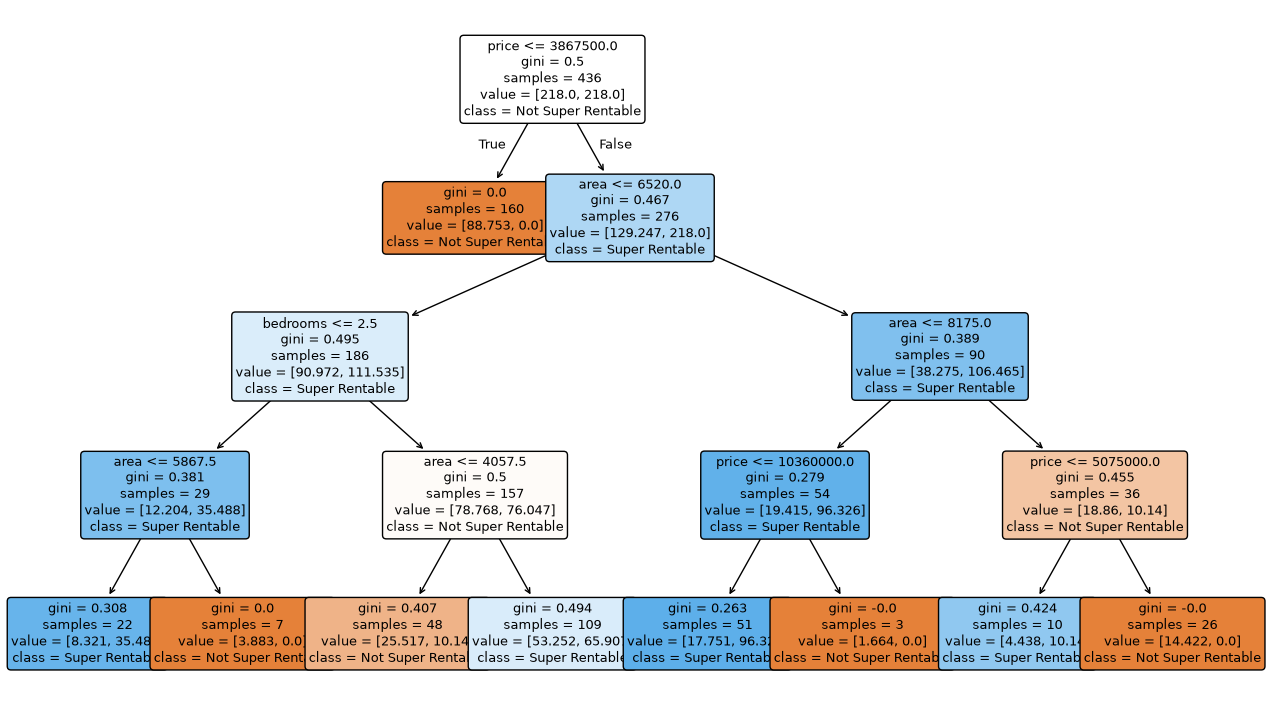

Accuracy: 0.6513761467889908
[[64 34]
 [ 4  7]]
                    precision    recall  f1-score   support

Not Super Rentable       0.94      0.65      0.77        98
    Super Rentable       0.17      0.64      0.27        11

          accuracy                           0.65       109
         macro avg       0.56      0.64      0.52       109
      weighted avg       0.86      0.65      0.72       109



In [28]:
# Features that are INDEPENDENT of how super_rentable was constructed
# define the predictor and independent/target variables
features = ['area', 'price', 'bedrooms']
X = df[features]
y = df['super_rentable']

# standard train test split step
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit on the tree model 
tree_model2 = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')  # class_weight='balanced' which helps the model handle imbalanced datasets by giving more importance to the minority class (super rentable houses) during training. max_depth = 4 is chosen to prevent overfitting while still allowing the model to capture some complexity in the data. A deeper tree could lead to overfitting, while a shallower tree might underfit and miss important patterns.
tree_model2.fit(X_train, y_train)

# Visualize it
plt.figure(figsize=(16, 9))
plot_tree(tree_model2, feature_names=features, class_names=['Not Super Rentable', 'Super Rentable'], filled=True, rounded=True, fontsize=9)
plt.show()

# Evaluate
y_pred = tree_model2.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Not Super Rentable', 'Super Rentable']))

### Graph Explanation
- Unlike the last tree (where every leaf hit gini = 0.0), almost every leaf here has gini > 0, meaning the model genuinely can't perfectly separate the classes using area/price/bedrooms. That's expected and healthy: these features don't determine rentability the way basement/guestroom/furnishing did by construction.
- Notice price is the split feature at almost every level of the tree. This tells you that, of your three features, price carries the most information about whether a house ends up "Super Rentable" in this dataset — likely because pricier houses tend to have more amenities (basement, guestroom, furnishing) bundled in, even though price wasn't part of your target's definition.
- Looking closely at which leaves actually get labeled "Super Rentable" (blue) vs. "Not Super Rentable" (orange), only two leaves are labeled Super Rentable, and together they contain just 5 of the 43 total Super Rentable houses in the training data. The rest get outvoted by the majority class within their leaf and are mislabeled - a preview of the recall problem the classification report confirms below.
- Accuracy = 0.899 (90%) looks like a solid result at a glance. But look at the class-level breakdown:
  - "Super Rentable" row: precision = 0.00, recall = 0.00, f1-score = 0.00. The model has zero ability to detect this class. It's not "sometimes wrong" — it never even tries.
  - The 90% accuracy is entirely a byproduct of the class imbalance: since 98 of 109 test houses (90%) are "Not Super Rentable," a model that blindly guesses that class every time gets ~90% "accuracy" for free, without learning anything.
- This is a textbook case of why accuracy is a bad metric on imbalanced datasets — it can look great while the model is functionally useless for the class you probably actually care about (identifying which houses ARE Super Rentable).

#### Now, Re-run the graph code and add 'class_weight='balanced' to the DecisionTreeClassifier() and see what happens...
- The tree is deeper and more balanced in structure, it's now actually trying to carve out regions for "Super Rentable," rather than mostly just refining "Not Super Rentable" regions like before!
- Accuracy dropped a lot (90% → 65%) — but this is expected, and honestly the right tradeoff here, not a step backward. The model is now catching 7 of 11 actual Super Rentable houses (recall = 0.64) instead of 0. That's the entire point of class_weight='balanced' — it explicitly sacrifices overall accuracy to force the model to actually try on the minority class instead of ignoring it.
- But precision cratered to 0.17 — meaning most of what the model calls "Super Rentable" is now wrong. Look at the confusion matrix: [[64, 34], [4, 7]]. It's now predicting "Super Rentable" 41 times total (34 + 7), but only 7 of those are actually correct. It went from "never guesses this class" to "guesses this class a lot, and is usually wrong when it does" — that's the cost of forcing recall up.


What we just experienced is called the *precision-recall tradeoff*: you can't maximize both metrics simultaneously, especially with only 43 minority-class examples to learn from in the first place. Which one matters more depends entirely on the real-world use case:
- If missing a genuinely "Super Rentable" house is costly (e.g., you'd lose potential rental income by not flagging it) → recall matters more, and this balanced version is the better model despite lower accuracy.
- If falsely flagging a house as "Super Rentable" is costly (e.g., you'd waste money renovating/marketing a house that doesn't actually qualify) → precision matters more, and your original unweighted model — despite recall=0 — might paradoxically look "safer," even though it's really just refusing to ever commit.

Neither model is unambiguously "better" — it depends on which mistake is more expensive in the actual scenario you're modeling.

Note: 
-  max_depth & min_samples_leaf / min_samples_split: other tweaks that can help overfitting
- feature_importances_ : we've been inferring that price mattered most by eyeballing the tree structure; sklearn actually gives you this as a direct attribute (tree_model.feature_importances_) instead of reading it off the diagram.
- Cross-validation — we've been using a single train/test split every time. That's fine for learning, but a single split can be lucky/unlucky by chance; cross-validation (cross_val_score) checks stability across multiple splits.
- The splitting criterion itself (gini vs entropy) — we've only seen gini; entropy is an alternative that usually gives similar results but is worth knowing exists.



---
## 4. Random Forest
A method that builds many decision trees and combines their results to make a more accurate and stable prediction. Why is this better than a single decision tree? Because a single tree is prone to overfitting and may not generalize well to unseen data. By building an ensemble of trees, we reduce variance and improve predictive performance - each tree makes its own imperfect prediction, but averaging/voting across many of them smooths out the noise any individual tree overfits to. 

How does it work?: Random forests introduce randomness in two ways:
1. **Bootstrap sampling (bagging)**: it creates multiple random subsets of the training data by sampling rows *with replacement* - meaning some rows may be picked multiple times for a given tree's subset, and others not at all. Each subset trains a separate decision tree.
2. **Random feature selection**: at *each split* within each tree, only a random subset of features is considered, rather than all of them. This is the part that's easy to miss - without it, every tree would likely pick the same dominant feature (like `price`, which dominated our earlier single tree) at the top every time, producing many highly-correlated trees that don't actually diversify predictions much. Random feature selection is what forces the trees to differ meaningfully from one another.

Together, these two sources of randomness mean each tree sees a different "slice" of the data and a different "menu" of features to split on - so their individual mistakes tend to be different from each other, and averaging cancels much of that noise out.

**Question to ask now**: given the class imbalance and overfitting risk we saw with a single decision tree on the "super rentable" problem, *does averaging across many randomized trees (with `class_weight='balanced'`) improve recall on the minority class without sacrificing as much precision/accuracy as the single balanced tree did?* In other words, can we use an ensemble method like Random Forest to improve the model's performance on the minority class (super rentable houses) while still maintaining good overall accuracy and precision?


Accuracy: 0.7155963302752294
[[72 26]
 [ 5  6]]
                    precision    recall  f1-score   support

Not Super Rentable       0.94      0.73      0.82        98
    Super Rentable       0.19      0.55      0.28        11

          accuracy                           0.72       109
         macro avg       0.56      0.64      0.55       109
      weighted avg       0.86      0.72      0.77       109



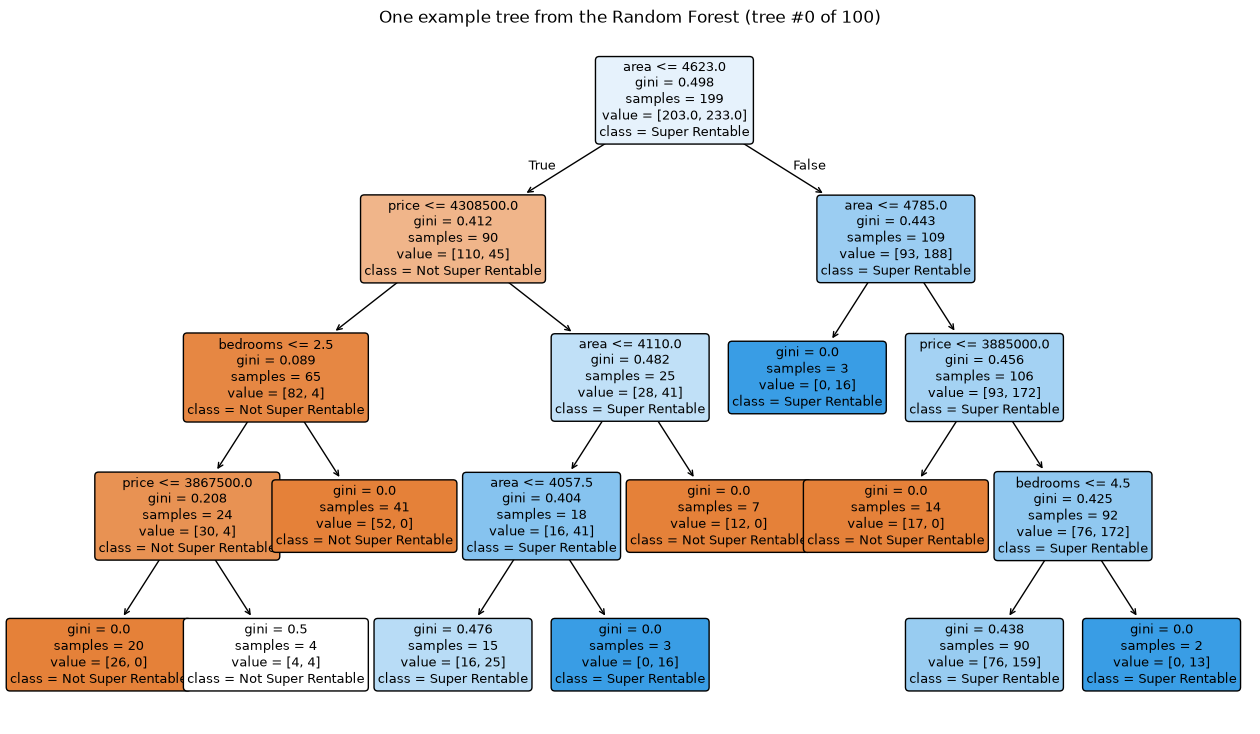

In [29]:
# Reuse the same features and target as the single-tree experiment
features = ['area', 'price', 'bedrooms']
X = df[features]
y = df['super_rentable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees in the forest
    max_depth=4,            # cap depth per tree, same as the single tree comparison
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", rf_model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Not Super Rentable', 'Super Rentable']))

plt.figure(figsize=(16, 9))
plot_tree(rf_model.estimators_[0], feature_names=features, 
          class_names=['Not Super Rentable', 'Super Rentable'],
          filled=True, rounded=True, fontsize=9)
plt.title("One example tree from the Random Forest (tree #0 of 100)")
plt.show()

### Graph Explanation ( compared to simple decision tree )

#### What actually happened: 
- Accuracy improved (0.651 → 0.716) and precision improved slightly (0.17 → 0.19) — the forest is a bit less trigger-happy about calling something "Super Rentable" than the single tree was (it predicted "Super Rentable" 32 times vs. the single tree's 41 times), and when it does, it's right slightly more often.
- Recall actually dropped (0.64 → 0.55) — the forest now only catches 6 of 11 actual Super Rentable houses, versus 7 of 11 before. F1-score (which balances precision and recall) barely moved at all (0.27 → 0.28) — essentially no meaningful improvement on the metric that matters most for this imbalanced problem.

#### So did random forest "win"?
Not really, and that's an important, honest result to sit with. 
The hypothesis was: *does averaging many randomized trees improve recall on the minority class without sacrificing as much as the single tree did?* The answer here is no — the forest traded a bit of recall for a bit of precision and accuracy, landing at almost the same overall f1-score. It didn't meaningfully solve the imbalance problem; it just shifted where the model sits on the same precision-recall tradeoff.

Why might this be happening, given what you know about random forests? With only 43 positive examples in the entire dataset (and even fewer after bootstrap sampling shrinks each tree's view further), each individual tree in the forest has very few "Super Rentable" examples to learn from — sometimes even fewer than the full dataset had, since bootstrap sampling can under-represent an already-rare class in any given tree's subset. Averaging 100 trees that each struggle to see the minority class clearly doesn't necessarily produce a forest that's dramatically better at spotting it — ensembling helps most when the underlying signal is present but noisy, not when the signal is fundamentally starved of examples to begin with.

#### The real lesson here
This is a case where the model wasn't really the bottleneck — the data was. No amount of switching between decision tree → random forest → gradient boosting is likely to fix a problem that's fundamentally "I only have 43 positive examples out of 436." That's exactly the scenario where the resampling techniques I mentioned earlier (oversampling the minority class, e.g. SMOTE) tend to matter more than which algorithm you pick — because they address the actual constraint (not enough positive examples to learn from) rather than working around it.

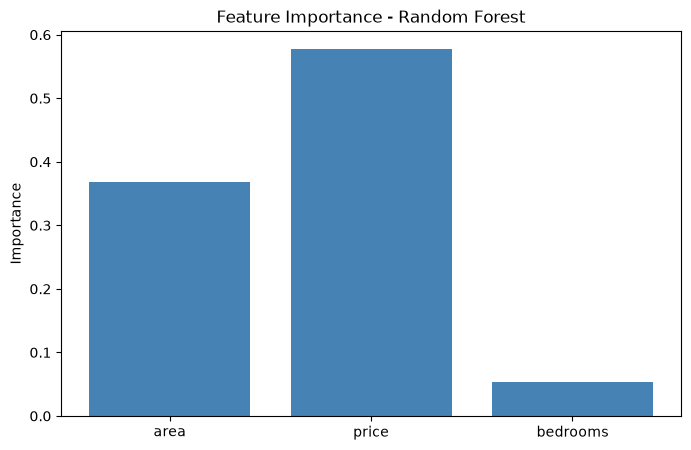

{'area': np.float64(0.3688216123548865), 'price': np.float64(0.5770824373493206), 'bedrooms': np.float64(0.05409595029579293)}


In [30]:
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(features, importances, color='steelblue')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()

print(dict(zip(features, importances)))

---
## **Review of Supervised Learning**

### Regression:

- Linear regression (your very first model, price ~ area)
- Logistic regression (the "regression that's actually classification" one)

### Classification:

- Decision trees (single tree, multiple depths, class_weight='balanced')
- Random forest (bagging + random feature subsets)
- Gradient boosting (sequential error-correcting trees, sample_weight)

### Cross-cutting concepts (arguably more valuable than the model list itself):

- Overfitting, gini impurity, feature importance
- Data leakage
- Class imbalance, precision/recall/f1 tradeoffs
- Accuracy as a misleading metric
- Data volume problem, not model choice

---

## **Un-Supervised Learning Models - Models that are used to find patterns in data without predefined labels**

*The mental shift here is significant:* There's no y anymore. Every model you've built so far had a target to predict and a "right answer" to check against (accuracy, recall, etc.). Unsupervised learning has neither — you're just handing the model X and asking it to find structure on its own, with no ground truth to validate against. That changes how you evaluate success entirely (no more confusion matrices).